<a href="https://colab.research.google.com/github/HUGOBROWNING/google-stock-quant-forecasting/blob/main/Google_Analysis_Part_2_(Deep_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import yfinance as yf

ticker='GOOGL'
start='2010-06-01'
end = '2026-06-01'

raw =yf.download(
    ticker,
    start = start,
    end = end
)

if isinstance(raw.columns, pd.MultiIndex):
  raw.columns=raw.columns.get_level_values(0)

raw = raw.sort_index()
raw = raw[raw['Volume'] > 0].dropna(
    subset = [
        'Close'
    ]
)
raw.head()

/tmp/ipykernel_16690/834280377.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw =yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-06-01,11.965221,12.180778,11.909410,11.917100,106565328
2010-06-02,12.238078,12.250480,11.942650,12.072132,101530368
2010-06-03,12.541444,12.600976,12.271069,12.281238,145881972
2010-06-04,12.370786,12.631983,12.320680,12.395591,156655188
2010-06-07,12.043359,12.425108,11.984571,12.379219,145162692


<Axes: xlabel='Close'>

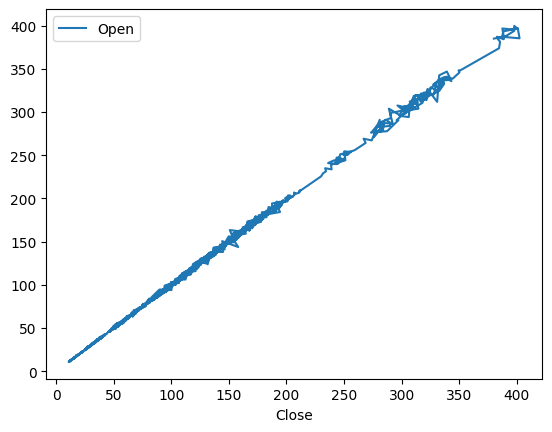

In [2]:
data=raw.copy()
data.plot(x='Close', y='Open')

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [4]:
display(data.head(6), data.tail(6))

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-06-01,11.965221,12.180778,11.909410,11.917100,106565328
2010-06-02,12.238078,12.250480,11.942650,12.072132,101530368
2010-06-03,12.541444,12.600976,12.271069,12.281238,145881972
2010-06-04,12.370786,12.631983,12.320680,12.395591,156655188
2010-06-07,12.043359,12.425108,11.984571,12.379219,145162692
2010-06-08,12.025002,12.125711,11.845413,12.101153,107296596


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-05-21,387.428589,392.265696,382.791344,385.469767,24852800
2026-05-22,382.741394,388.507939,381.542098,387.118784,20442100
2026-05-26,388.647858,389.027636,382.371608,384.280471,27747400
2026-05-27,388.597870,393.644874,385.669626,386.439186,23087300
2026-05-28,389.897125,391.636077,384.930091,387.768392,24357500
2026-05-29,380.112946,385.010014,378.234063,385.010014,44415800


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-06-01 to 2026-05-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4024 non-null   float64
 1   High    4024 non-null   float64
 2   Low     4024 non-null   float64
 3   Open    4024 non-null   float64
 4   Volume  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [6]:
data.describe()

Price,Close,High,Low,Open,Volume
count,4024.000000,4024.000000,4024.000000,4024.000000,4.024000e+03
mean,78.264077,79.075867,77.384921,78.217169,5.196488e+07
std,71.502536,72.300653,70.575124,71.412973,4.279580e+07
min,10.816750,10.970787,10.756224,10.872312,9.312000e+06
25%,27.003925,27.202417,26.826621,27.012225,2.701542e+07
50%,53.559074,54.164959,52.927182,53.575188,3.589500e+07
75%,116.957161,118.112543,115.614815,117.009567,6.458450e+07
max,402.379669,408.366081,396.123378,399.681282,5.923990e+08


In [7]:
data.dtypes

,0
Price,
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [8]:
data.columns.tolist()

['Close', 'High', 'Low', 'Open', 'Volume']

In [9]:
x, y = data.shape
print(f"Rows: {x} || Columns: {y}")

Rows: 4024 || Columns: 5


In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data=scaler.fit_transform(
    data['Close'].values.reshape(
        -1,
        1
    )
)

<Axes: >

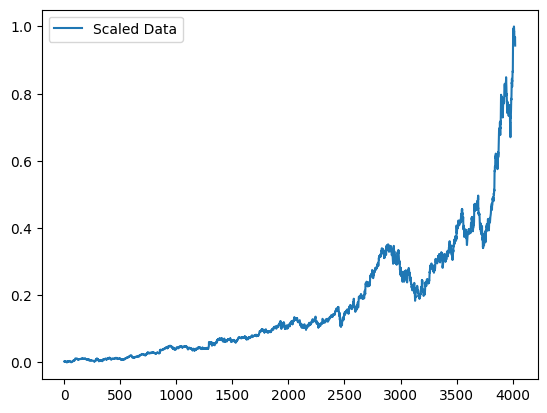

In [11]:
pd.DataFrame(
    {
        'Scaled Data': scaled_data.flatten()
    }
).plot()

In [12]:
def create_sequences(t, l):
    "Let 'l' be the sequence length and t b the data/array"
    X, y =[], []

    for k in range(l, len(t)):
        X.append(t[k-l: k, 0])
        y.append(t[k, 0])

    return np.array(X), np.array(y)

l =60

X, y =create_sequences(scaled_data, l)

X=X.reshape(
    (
        X.shape[0],
        X.shape[1],
        1
    )
)

In [13]:
train_size = int(0.8*len(X))
X_train,X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [14]:
def build_RNN():
  model = Sequential(
      [
          SimpleRNN(
              128,
              activation ='tanh',
              return_sequences=True,
              input_shape=(X_train.shape[1], 1)
          ),
          Dropout(0.2),
          SimpleRNN(64, activation = "tanh", return_sequences = True),
          SimpleRNN(32, activation = "relu"),
          Dense(1,activation='linear')
      ]
  )
  model.compile(loss='mse', metrics=['mae'], optimizer='adam')
  return model

rnn_model = build_RNN()
history = rnn_model.fit(X_train, y_train, epochs = 15, batch_size = 16,
              validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.0078 - mae: 0.0388 - val_loss: 0.0181 - val_mae: 0.0805
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 3.2561e-04 - mae: 0.0132 - val_loss: 0.0129 - val_mae: 0.0660
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 2.7945e-04 - mae: 0.0121 - val_loss: 0.0117 - val_mae: 0.0729
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 2.0773e-04 - mae: 0.0105 - val_loss: 0.0079 - val_mae: 0.0545
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 1.4792e-04 - mae: 0.0088 - val_loss: 0.0114 - val_mae: 0.0839
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 1.6513e-04 - mae: 0.0096 - val_loss: 0.0058 - val_mae: 0.0476
Epoch 7/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 1.4598e-04 - mae: 0.0092 - val_loss: 0.0076 - val_mae: 0.0501
Epoch 8/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 1.2951e-04 - mae: 0.0085 - val_loss: 0.0064 - val_mae: 0.0447
Epoch 9/15
1

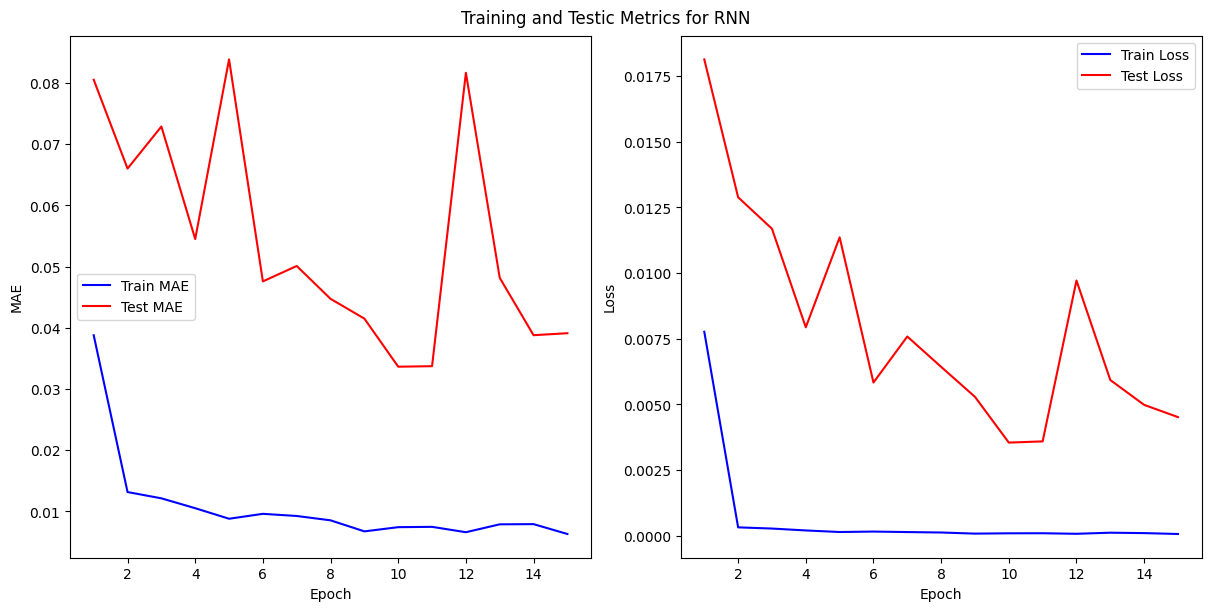

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae=history.history['mae']
val_mae=history.history['val_mae']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(mae)+1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout = True)

axes[0].plot(epochs, mae, 'b', label='Train MAE')
axes[0].plot(epochs, val_mae, 'r', label='Test MAE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(epochs, loss, 'b', label='Train Loss')
axes[1].plot(epochs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle(f'Training and Testic Metrics for RNN')

plt.show();

In [16]:
from tensorflow.keras.layers import LSTM

def build_lstm():
  model = Sequential([
    LSTM(128, activation = "tanh", return_sequences = True,
                    input_shape = (X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, activation = "tanh", return_sequences = True),
    LSTM(32, activation = "relu"),
    Dense(1,activation='linear')
])
  model.compile(loss='mse', metrics=['mae'], optimizer='adam')
  return model

lstm_model = build_lstm()
history = lstm_model.fit(X_train, y_train, epochs = 15, batch_size = 16,
              validation_data=(X_test, y_test))

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - loss: 4.2541e-04 - mae: 0.0100 - val_loss: 0.0019 - val_mae: 0.0279
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 8.3256e-05 - mae: 0.0062 - val_loss: 0.0022 - val_mae: 0.0299
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 7.5749e-05 - mae: 0.0060 - val_loss: 0.0033 - val_mae: 0.0421
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 8.1389e-05 - mae: 0.0062 - val_loss: 0.0024 - val_mae: 0.0336
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 7.5745e-05 - mae: 0.0059 - val_loss: 9.8143e-04 - val_mae: 0.0207
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 5.9278e-05 - mae: 0.0052 - val_loss: 0.0021 - val_mae: 0.0314
Epoch 7/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 4.9890e-05 - mae: 0.0047 - val_loss: 0.0022 - val_mae: 0.0320
Epoch 8/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - loss: 5.2307e-05 - mae: 0.0050 - val_loss: 9.4510e-04 - val_mae:

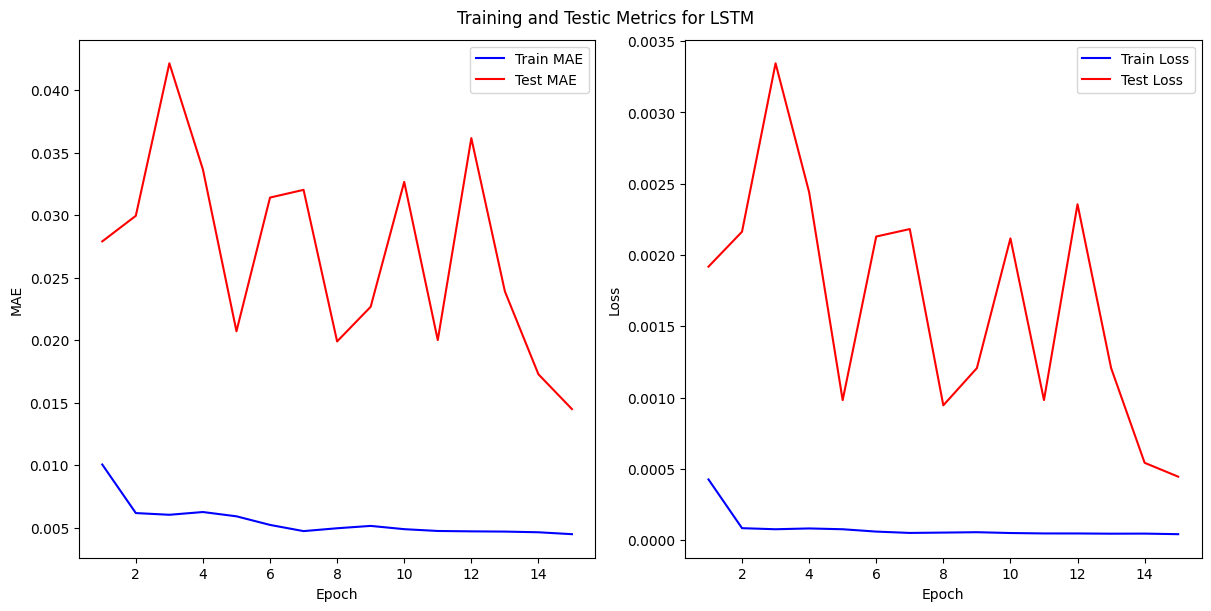

In [17]:
mae =history.history['mae']
val_mae=history.history['val_mae']
loss = history.history['loss']
val_loss=history.history['val_loss']

epochs = range(1, len(mae)+1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout = True)

axes[0].plot(epochs, mae, 'b', label='Train MAE')
axes[0].plot(epochs, val_mae, 'r', label='Test MAE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(epochs, loss, 'b', label='Train Loss')
axes[1].plot(epochs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle(f'Training and Testic Metrics for LSTM')

plt.show();

In [18]:
from tensorflow.keras.layers import GRU

def build_gru():
  model = Sequential([
    GRU(128, activation = "tanh", return_sequences = True,
                    input_shape = (X_train.shape[1], 1)),
    Dropout(0.2),
    GRU(64, activation = "tanh", return_sequences = True),
    GRU(32, activation = "relu"),
    Dense(1,activation='linear')
])
  model.compile(loss='mse', metrics=['mae'], optimizer='adam')
  return model

gru_model = build_gru()
history = gru_model.fit(X_train, y_train, epochs = 15, batch_size = 16,
              validation_data=(X_test, y_test))

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 36s 136ms/step - loss: 8.0619e-04 - mae: 0.0116 - val_loss: 6.3824e-04 - val_mae: 0.0180
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 5.2676e-05 - mae: 0.0052 - val_loss: 5.3709e-04 - val_mae: 0.0155
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - loss: 4.5244e-05 - mae: 0.0047 - val_loss: 5.3090e-04 - val_mae: 0.0150
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - loss: 4.8995e-05 - mae: 0.0050 - val_loss: 9.8111e-04 - val_mae: 0.0207
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - loss: 5.1836e-05 - mae: 0.0052 - val_loss: 0.0011 - val_mae: 0.0226
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - loss: 4.6236e-05 - mae: 0.0049 - val_loss: 0.0010 - val_mae: 0.0220
Epoch 7/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - loss: 3.5376e-05 - mae: 0.0040 - val_loss: 8.3478e-04 - val_mae: 0.0202
Epoch 8/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - loss: 3.6368e-05 - mae: 0.0042 - val_loss: 4.103

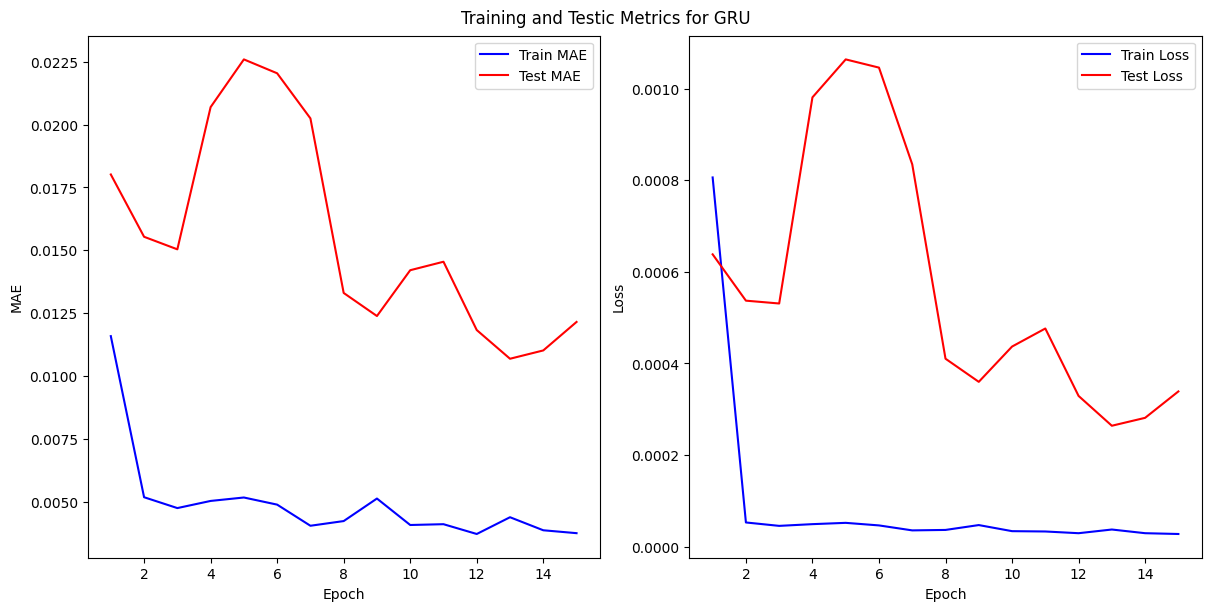

In [19]:
mae = history.history['mae']
val_mae = history.history['val_mae']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(mae)+1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), constrained_layout = True)

axes[0].plot(epochs, mae, 'b', label='Train MAE')
axes[0].plot(epochs, val_mae, 'r', label='Test MAE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(epochs, loss, 'b', label='Train Loss')
axes[1].plot(epochs, val_loss, 'r', label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle(f'Training and Testic Metrics for GRU')

plt.show();

In [20]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

rnn_pred_rescaled = scaler.inverse_transform(rnn_pred)
lstm_pred_rescaled = scaler.inverse_transform(lstm_pred)
gru_pred_rescaled = scaler.inverse_transform(gru_pred)

actual_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_rescaled = scaler.inverse_transform(y_pred)
    y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    rmse = math.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
    r2 = r2_score(y_test_rescaled, y_pred_rescaled)

    return mae, rmse, r2

mae_rnn, rmse_rnn, r2_rnn = evaluate_model(rnn_model, X_test, y_test)
mae_lstm, rmse_lstm, r2_lstm = evaluate_model(lstm_model, X_test, y_test)
mae_gru, rmse_gru, r2_gru = evaluate_model(gru_model, X_test, y_test)

print(f"RNN - MAE: {mae_rnn}, RMSE: {rmse_rnn}, R²: {r2_rnn}")
print(f"LSTM - MAE: {mae_lstm}, RMSE: {rmse_lstm}, R²: {r2_lstm}")
print(f"GRU - MAE: {mae_gru}, RMSE: {rmse_gru}, R²: {r2_gru}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
RNN - MAE: 15.316249525111079, RMSE: 26.32388629130025, R²: 0.8629463683644313
LSTM - MAE: 5.670446571455928, RMSE: 8.256966085028544, R²: 0.9865156027871567
GRU - MAE: 4.75722974125404, RMSE: 7.207940908247024, R²: 0.9897242632250874


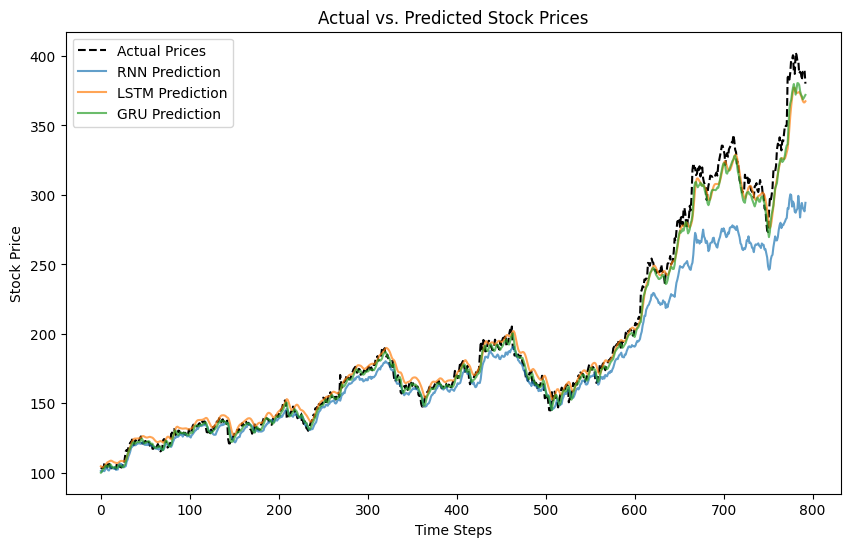

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(actual_rescaled, label='Actual Prices', color='black', linestyle='dashed')

plt.plot(rnn_pred_rescaled, label='RNN Prediction', alpha=0.7)
plt.plot(lstm_pred_rescaled, label='LSTM Prediction', alpha=0.7)
plt.plot(gru_pred_rescaled, label='GRU Prediction', alpha=0.7)

plt.title('Actual vs. Predicted Stock Prices')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [23]:
!pip install keras-tuner --upgrade

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from keras_tuner import HyperModel

def build_gru(hp):
    model = Sequential([
        GRU(
            units=hp.Int('units', min_value=32, max_value=128, step=16),
            activation='tanh',
            return_sequences=False,
            input_shape=(X_train.shape[1], 1)
        ),
        Dropout(hp.Choice('dropout_rate', values=[0.2, 0.3, 0.4, 0.5])),
        Dense(1)
    ])

    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

In [ ]:
from tensorflow.keras.layers import LSTM

def build_lstm(hp):
    model = Sequential([
        LSTM(
            units=hp.Int('units', min_value=32, max_value=128, step=16),
            activation='tanh',
            return_sequences=False,
            input_shape=(X_train.shape[1], 1)
        ),
        Dropout(hp.Choice('dropout_rate', values=[0.2, 0.3, 0.4, 0.5])),
        Dense(1)
    ])

    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [58]:
import keras_tuner as kt

tuner_gru = kt.RandomSearch(
    build_gru,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='gru_tuning',
    project_name='gru_finetuning'
)

tuner_gru.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping])

Reloading Tuner from gru_tuning/gru_finetuning/tuner0.json


In [59]:
tuner_lstm = kt.RandomSearch(
    build_lstm,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='lstm_finetuning'
)

tuner_lstm.search(X_train, y_train, epochs=25, validation_data=(X_test, y_test), callbacks=[early_stopping])

Reloading Tuner from lstm_tuning/lstm_finetuning/tuner0.json


In [45]:
best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
print(f"Best GRU units: {best_hps_gru.get('units')}")
print(f"Best GRU dropout rate: {best_hps_gru.get('dropout_rate')}")
print(f"Best GRU optimizer: {best_hps_gru.get('optimizer')}")

Best GRU units: 32
Best GRU dropout rate: 0.4
Best GRU optimizer: adam


In [46]:
best_gru_model = tuner_gru.hypermodel.build(best_hps_gru)
history_gru = best_gru_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0021 - mae: 0.0284 - val_loss: 4.4899e-04 - val_mae: 0.0172
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 5.5770e-04 - mae: 0.0152 - val_loss: 3.0368e-04 - val_mae: 0.0123
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 4.3345e-04 - mae: 0.0134 - val_loss: 2.2969e-04 - val_mae: 0.0108
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 3.8504e-04 - mae: 0.0125 - val_loss: 2.0128e-04 - val_mae: 0.0101
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 3.1487e-04 - mae: 0.0118 - val_loss: 1.9015e-04 - val_mae: 0.0098
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 2.5305e-04 - mae: 0.0101 - val_loss: 1.9395e-04 - val_mae: 0.0101
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.7524e-04 - mae: 0.0105 - val_loss: 2.9378e-04 - val_mae: 0.0138
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 2.4227e-04 - mae: 0.0101 - val_loss: 2.4537e-04 - val_mae: 0.0107

In [60]:
best_hps_lstm = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
best_lstm_model= tuner_lstm.hypermodel.build(best_hps_lstm)
history_lstm=best_lstm_model.fit(X_train, y_train, epochs = 50, validation_data = (X_test, y_test), callbacks = [early_stopping])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - loss: 8.0239e-04 - mae: 0.0177 - val_loss: 0.0021 - val_mae: 0.0339
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 2.4368e-04 - mae: 0.0116 - val_loss: 7.1984e-04 - val_mae: 0.0209
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 2.0968e-04 - mae: 0.0106 - val_loss: 8.4922e-04 - val_mae: 0.0199
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - loss: 1.8037e-04 - mae: 0.0099 - val_loss: 0.0017 - val_mae: 0.0374
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.6005e-04 - mae: 0.0093 - val_loss: 0.0047 - val_mae: 0.0619
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 1.4365e-04 - mae: 0.0088 - val_loss: 8.5214e-04 - val_mae: 0.0208
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 1.3910e-04 - mae: 0.0087 - val_loss: 9.6892e-04 - val_mae: 0.0243


In [48]:
from jax import legacy_prng_key
gru_predictions=best_gru_model.predict(X_test)
lstm_predictions = best_lstm_model.predict(X_test)

gru_pred_rescaled = scaler.inverse_transform(gru_predictions)
lstm_pred_rescaled = scaler.inverse_transform(lstm_predictions)
actual_rescaled = scaler.inverse_transform(y_test.reshape(
    -1,
    1
))

def MSE(y_test, y_pred):
  n = len(y_test)

  ssr=np.sum((y_test - y_pred)**2)

  return ssr/n

def MAE(y_test, y_pred):
  n=len(y_test)

  mae = np.mean(np.abs(y_test-y_pred))
  return mae

def R2_adj(y_test, y_pred, j):
  n=len(y_test)
  ssr=np.sum((y_test - y_pred)**2)
  sst = np.sum((y_test - np.mean(y_test))**2)

  r2=1- (ssr / sst)
  numerator = (1-r2)*(n-1)
  denominator = (n-j-1)

  return 1- (numerator / denominator)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gru_predictions = best_gru_model.predict(X_test)
lstm_predictions = best_lstm_model.predict(X_test)

gru_pred_rescaled = scaler.inverse_transform(gru_predictions)
lstm_pred_rescaled = scaler.inverse_transform(lstm_predictions)
actual_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

gru_mae = mean_absolute_error(actual_rescaled, gru_pred_rescaled)
gru_rmse = np.sqrt(mean_squared_error(actual_rescaled, gru_pred_rescaled))
gru_r2 = r2_score(actual_rescaled, gru_pred_rescaled)

lstm_mae = mean_absolute_error(actual_rescaled, lstm_pred_rescaled)
lstm_rmse = np.sqrt(mean_squared_error(actual_rescaled, lstm_pred_rescaled))
lstm_r2 = r2_score(actual_rescaled, lstm_pred_rescaled)

print(f"Fine-Tuned GRU - MAE: {gru_mae:.4f}, RMSE: {gru_rmse:.4f}, R²: {gru_r2:.4f}")
print(f"Fine-Tuned LSTM - MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, R²: {lstm_r2:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Fine-Tuned GRU - MAE: 3.3735, RMSE: 4.8317, R²: 0.9954
Fine-Tuned LSTM - MAE: 8.1979, RMSE: 10.5056, R²: 0.9782


## Model Performance Comparison

Let's compare the performance of all models (initial and fine-tuned) using a table to clearly see the improvements after hyperparameter tuning.

## Resources

### 2. Deep Learning Performance
| Model | MAE | RMSE | R-squared | Directional Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Fine-tuned GRU** | 3.37 | 4.83 | 0.99 | *[XX%]* |
| **Initial GRU** | 4.76 | 7.21 | 0.99 | *[XX%]* |
| **Initial LSTM** | 5.67 | 8.26 | 0.99 | *[XX%]* |
| **Fine-tuned LSTM** | 8.20 | 10.51 | 0.98 | *[XX%]* |
| **Initial RNN** | 15.32 | 26.32 | 0.86 | *[XX%]* |

> **Summary:** The Fine-tuned GRU model outperformed the Initial RNN by approximately 81.6% in RMSE, successfully capturing long-term temporal dependencies in stock trends without suffering from severe vanishing gradient issues.

In [62]:
metrics = {
    'Model': ['Initial RNN', 'Initial LSTM', 'Initial GRU', 'Fine-tuned GRU', 'Fine-tuned LSTM'],
    'MAE': [mae_rnn, mae_lstm, mae_gru, gru_mae, lstm_mae],
    'RMSE': [rmse_rnn, rmse_lstm, rmse_gru, gru_rmse, lstm_rmse],
    'R-squared': [r2_rnn, r2_lstm, r2_gru, gru_r2, lstm_r2]
}

metrics_df = pd.DataFrame(metrics)
metrics_df_sorted = metrics_df.sort_values(by='RMSE', ascending=True)

print("Performance Metrics for All Models:")
display(metrics_df_sorted)


Performance Metrics for All Models:


,Model,MAE,RMSE,R-squared
3,Fine-tuned GRU,3.373477,4.831708,0.995383
2,Initial GRU,4.757230,7.207941,0.989724
1,Initial LSTM,5.670447,8.256966,0.986516
4,Fine-tuned LSTM,8.197898,10.505571,0.978171
0,Initial RNN,15.316250,26.323886,0.862946


## Fine-tuned GRU Model Learning Curves

Visualizing the training and validation loss and MAE for the fine-tuned GRU model.

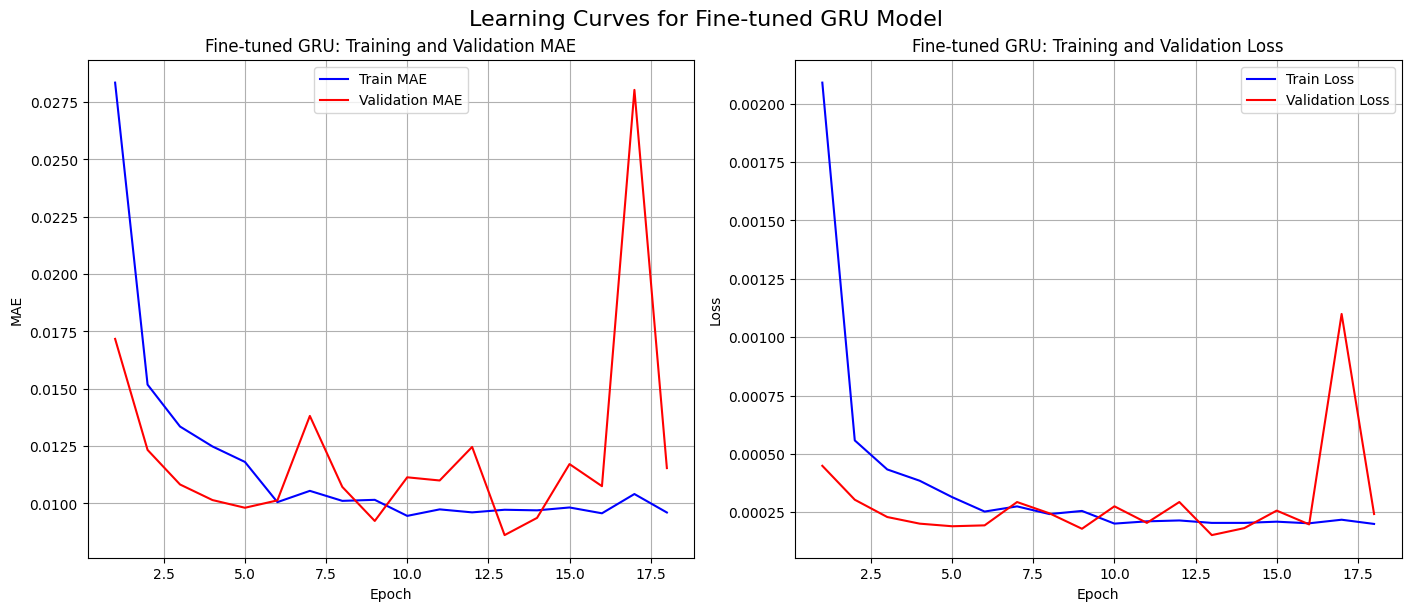

In [63]:
import matplotlib.pyplot as plt
import numpy as np

mae_gru_tuned = []
val_mae_gru_tuned = []

if 'mae' in history_gru.history:
    mae_gru_tuned = history_gru.history['mae']
    val_mae_gru_tuned = history_gru.history['val_mae']
elif 'mean_absolute_error' in history_gru.history:
    mae_gru_tuned = history_gru.history['mean_absolute_error']
    val_mae_gru_tuned = history_gru.history['val_mean_absolute_error']
else:
    print("Warning: MAE metrics ('mae' or 'mean_absolute_error') not found in history. MAE plots will be empty.")

loss_gru_tuned = history_gru.history['loss']
val_loss_gru_tuned = history_gru.history['val_loss']

epochs_for_plot = range(1, len(loss_gru_tuned) + 1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), constrained_layout=True)

if mae_gru_tuned:
    axes[0].plot(epochs_for_plot[:len(mae_gru_tuned)], mae_gru_tuned, 'b', label='Train MAE')
    axes[0].plot(epochs_for_plot[:len(val_mae_gru_tuned)], val_mae_gru_tuned, 'r', label='Validation MAE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('Fine-tuned GRU: Training and Validation MAE')
    axes[0].legend()

    axes[0].grid(True)
else:
    axes[0].text(0.5, 0.5, 'MAE metrics not available', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Fine-tuned GRU: Training and Validation MAE')

axes[1].plot(epochs_for_plot, loss_gru_tuned, 'b', label='Train Loss')
axes[1].plot(epochs_for_plot, val_loss_gru_tuned, 'r', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Fine-tuned GRU: Training and Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Learning Curves for Fine-tuned GRU Model', fontsize=16)
plt.show()

## Fine-tuned LSTM Model Learning Curves

Visualizing the training and validation loss and MAE for the fine-tuned LSTM model.

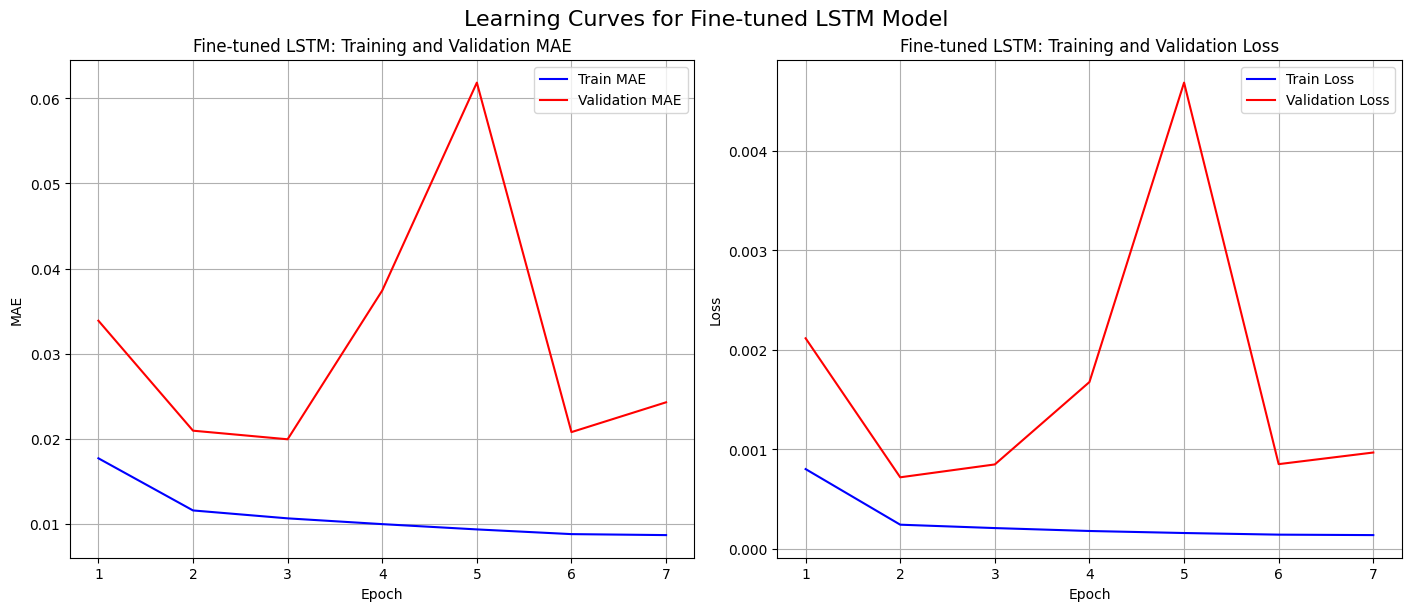

In [64]:
import matplotlib.pyplot as plt
import numpy as np

mae_lstm_tuned = []
val_mae_lstm_tuned = []

if 'mae' in history_lstm.history:
    mae_lstm_tuned = history_lstm.history['mae']
    val_mae_lstm_tuned = history_lstm.history['val_mae']
elif 'mean_absolute_error' in history_lstm.history:
    mae_lstm_tuned = history_lstm.history['mean_absolute_error']
    val_mae_lstm_tuned = history_lstm.history['val_mean_absolute_error']
else:
    print("Warning: MAE metrics ('mae' or 'mean_absolute_error') not found in history. MAE plots will be empty.")

loss_lstm_tuned = history_lstm.history['loss']
val_loss_lstm_tuned = history_lstm.history['val_loss']

epochs_for_plot = range(1, len(loss_lstm_tuned) + 1)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), constrained_layout=True)

if mae_lstm_tuned:
    axes[0].plot(epochs_for_plot[:len(mae_lstm_tuned)], mae_lstm_tuned, 'b', label='Train MAE')
    axes[0].plot(epochs_for_plot[:len(val_mae_lstm_tuned)], val_mae_lstm_tuned, 'r', label='Validation MAE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('Fine-tuned LSTM: Training and Validation MAE')
    axes[0].legend()
    axes[0].grid(True)
else:
    axes[0].text(0.5, 0.5, 'MAE metrics not available', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Fine-tuned LSTM: Training and Validation MAE')

axes[1].plot(epochs_for_plot, loss_lstm_tuned, 'b', label='Train Loss')
axes[1].plot(epochs_for_plot, val_loss_lstm_tuned, 'r', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Fine-tuned LSTM: Training and Validation Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Learning Curves for Fine-tuned LSTM Model', fontsize=16)
plt.show()

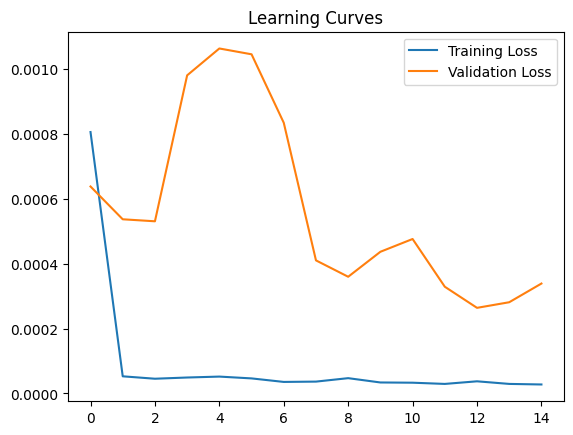

In [65]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.title('Learning Curves')
plt.show()